In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.research_config import ResearchConfig
from src.data_helpers import write_json
from src.forecast_calibration import label_forecasts
from src.forecast_calibration import summarize_forecasts


# 11 Static fOU Convergence Calibration

Label first passages directly from observed spread paths. Option exits do not determine forecast success or censoring. No backtest is rerun.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [ ]:
cfg = ResearchConfig().validate()


## 2. Load saved forecasts and label paths

The event starts at the signal date and ends H observed sessions later. Early option expiry alone is not censoring.


In [2]:
forecasts = pd.read_parquet("forecasts.parquet")
test_prices = pd.read_parquet("test_prices.parquet")
trades = pd.read_parquet("trades.parquet")
calibration = label_forecasts(forecasts, test_prices)
calibration.to_parquet("forecast_calibration.parquet")
summary = summarize_forecasts(calibration)
write_json("calibration_summary.json", summary)
display(pd.Series(summary))


n_forecasts           1903.000000
n_complete_horizon    1375.000000
n_censored             527.000000
mean_prediction          0.703042
observed_rate            0.335273
brier_score              0.358392
dtype: float64

## 3. Traded forecast subset

Headline rates use complete forecast windows; this avoids keeping early successes while dropping incomplete failures. Also report the separate traded-forecast population.


In [3]:
traded_forecasts = (
    forecasts.loc[forecasts.forecast_id.isin(trades.forecast_id)]
    if not trades.empty
    else forecasts.iloc[:0]
)
traded_calibration = label_forecasts(traded_forecasts, test_prices)
traded_calibration.to_parquet("traded_forecast_calibration.parquet")
traded_summary = summarize_forecasts(traded_calibration)
write_json("traded_forecast_calibration_summary.json", traded_summary)
display(pd.Series(traded_summary))
if not calibration.empty:
    display(calibration.event_status.value_counts())


n_forecasts           159.000000
n_complete_horizon    159.000000
n_censored              0.000000
mean_prediction         0.702698
observed_rate           0.308176
brier_score             0.368905
dtype: float64

event_status
failure     914
censored    527
success     462
Name: count, dtype: int64

## 4. Calibration by horizon and exit economics

Overlapping forecasts are not independent binomial trials. Mean predicted probability at the maximum horizon is not the selected-horizon target.


,n_forecasts,mean_prediction,observed_rate
horizon_bin,,,
"(20.0, 63.0]",181,0.704108,0.149171
"(63.0, 126.0]",1194,0.702881,0.363484


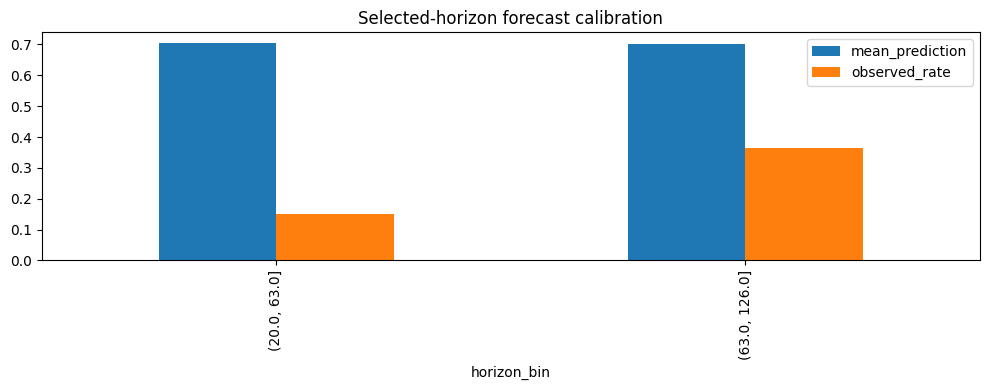

,n_trades,total_pnl,mean_return
exit_reason,,,
convergence,49,216360.780104,0.704334
expiry,110,-192746.964925,-0.252945


In [4]:
if not calibration.empty:
    complete = calibration.loc[calibration.complete_horizon_observed].copy()
    if not complete.empty:
        complete["horizon_bin"] = pd.cut(
            complete.convergence_horizon_trading_days, bins=[0, 5, 20, 63, 126, np.inf]
        )
        buckets = complete.groupby("horizon_bin", observed=True).agg(
            n_forecasts=("pair", "size"),
            mean_prediction=("probability_at_selected_horizon", "mean"),
            observed_rate=("realized_within_selected_horizon", "mean"),
        )
        buckets.index = buckets.index.astype(str)
        buckets.to_parquet("calibration_horizon_buckets.parquet")
        display(buckets)
        buckets[["mean_prediction", "observed_rate"]].plot.bar(
            figsize=(10, 4), title="Selected-horizon forecast calibration"
        )
        plt.tight_layout()
        plt.show()
if not trades.empty:
    display(
        trades.groupby("exit_reason").agg(
            n_trades=("pnl", "size"),
            total_pnl=("pnl", "sum"),
            mean_return=("trade_return", "mean"),
        )
    )


## Save module completion

Wait for this confirmation before moving to the next notebook.
